# Deteksi Jenis Sampah di Sekitar Kampus
## Image Classification menggunakan Transfer Learning (MobileNetV2)

NAMA   : HERRI SUBROTO NAINGGOLAN

NIM    : 4222301076

KELAS  : ROBOTIKA C PAGI SEMESTER 6

MATKUL :MACHINE LEARNING 


**Dataset:** [Trash Type Image Dataset](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset) — 6 kelas: `cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`


In [1]:
# ==== Import Libraries ====
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU tersedia:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.21.0
GPU tersedia: False


## 1. Download Dataset

Jalankan salah satu opsi di bawah (pilih sesuai environment kamu: Kaggle Notebook, Google Colab, atau lokal).

> **Catatan:** dataset ini terdiri dari 6 folder kelas berisi total ±2527 gambar. Struktur setelah diekstrak:
> ```
> dataset-resized/
>     cardboard/
>     glass/
>     metal/
>     paper/
>     plastic/
>     trash/
> ```


In [2]:
DATASET_DIR = "./TrashType_Image_Dataset"

EXPECTED_CLASSES = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}

def resolve_dataset_dir(path, max_depth=4):
    """Auto-descend jika ada folder pembungkus tambahan hasil extract zip,
    sampai ketemu folder yang langsung berisi 6 folder kelas."""
    current = path
    for _ in range(max_depth):
        if not os.path.isdir(current):
            raise FileNotFoundError(f"Folder tidak ditemukan: {current}")
        subitems = [d for d in os.listdir(current) if os.path.isdir(os.path.join(current, d))]
        if EXPECTED_CLASSES.issubset(set(subitems)):
            return current
       
        if len(subitems) == 1:
            current = os.path.join(current, subitems[0])
            continue
        break
    raise FileNotFoundError(
        f"Tidak ketemu 6 folder kelas ({EXPECTED_CLASSES}) di dalam '{path}'. "
        f"Cek struktur folder manual dengan `ls {path}` di terminal, lalu sesuaikan DATASET_DIR."
    )

DATASET_DIR = resolve_dataset_dir(DATASET_DIR)
CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
print("Dataset path terpakai:", DATASET_DIR)
print("Kelas:", CLASS_NAMES)

Dataset path terpakai: ./TrashType_Image_Dataset
Kelas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 2. Eksplorasi Data

{'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}


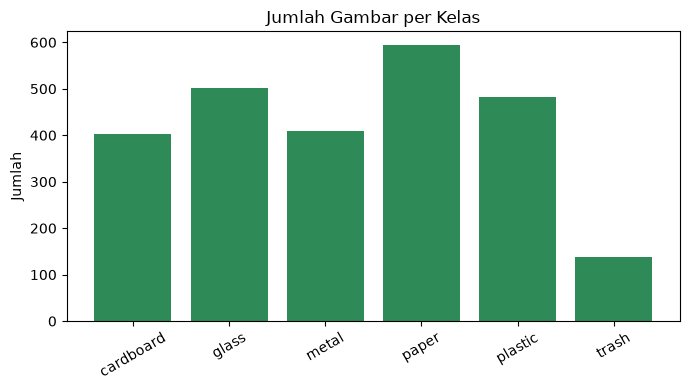

In [3]:
# ==== Hitung jumlah gambar per kelas ====
counts = {c: len(os.listdir(os.path.join(DATASET_DIR, c))) for c in CLASS_NAMES}
print(counts)

plt.figure(figsize=(7,4))
plt.bar(counts.keys(), counts.values(), color='seagreen')
plt.title("Jumlah Gambar per Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


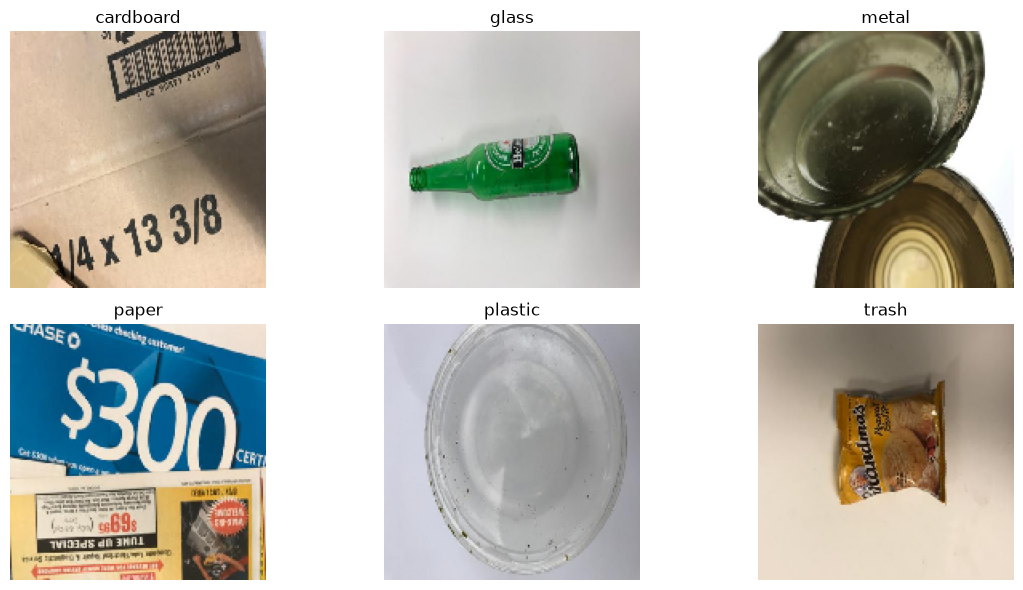

In [4]:
# ==== Tampilkan contoh gambar tiap kelas ====
import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12,6))
for i, c in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_DIR, c)
    fname = random.choice(os.listdir(folder))
    img = load_img(os.path.join(folder, fname), target_size=(160,160))
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')
plt.tight_layout()
plt.show()


## 3. Split Data & Data Generator

Data dibagi 70% training dan 30% validation menggunakan `ImageDataGenerator`. Augmentasi (rotasi, shift, zoom, flip, brightness) diterapkan pada data training untuk memperkaya variasi visual sampah (posisi, pencahayaan, sudut foto) yang realistis untuk kondisi pengambilan gambar di sekitar kampus.


In [5]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.30,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

datagen_val = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.30
)

train_gen = datagen_train.flow_from_directory(
    DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)

val_gen = datagen_val.flow_from_directory(
    DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)

print("Train samples:", train_gen.samples)
print("Val samples:", val_gen.samples)
print("Class indices:", train_gen.class_indices)


Found 1771 images belonging to 6 classes.
Found 756 images belonging to 6 classes.
Train samples: 1771
Val samples: 756
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 4. Transfer Learning Tahap — Feature Extraction

Sesuai konsep transfer learning: gunakan **MobileNetV2 pre-trained (ImageNet)** sebagai *feature extractor*. Seluruh layer base model **dibekukan (`trainable = False`)** sehingga bobot hasil training ImageNet tidak berubah — hanya classifier head baru (`GlobalAveragePooling2D` + `Dense` + `Dropout` + `Dense` output) yang dilatih dari awal untuk mengenali 6 kelas sampah.

Tahap ini murah secara komputasi karena hanya sedikit parameter (head) yang dilatih, dan cocok untuk dataset berukuran kecil-menengah seperti dataset ini (±2500 gambar).


In [6]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False   # Tahap 1: freeze seluruh base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(CLASS_NAMES), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total layer base model : {len(base_model.layers)}")
print(f"Layer trainable        : {sum(l.trainable for l in base_model.layers)}")
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total layer base model : 154
Layer trainable        : 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS_STAGE1 = 25

history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks
)


Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 604ms/step - accuracy: 0.6369 - loss: 0.9552 - val_accuracy: 0.7738 - val_loss: 0.7142 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 548ms/step - accuracy: 0.7899 - loss: 0.5746 - val_accuracy: 0.7950 - val_loss: 0.6183 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 563ms/step - accuracy: 0.8300 - loss: 0.4684 - val_accuracy: 0.7672 - val_loss: 0.7320 - learning_rate: 0.0010
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 615ms/step - accuracy: 0.8413 - loss: 0.4214 - val_accuracy: 0.8056 - val_loss: 0.6046 - learning_rate: 0.0010
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 636ms/step - accuracy: 0.8763 - loss: 0.3301 - val_accuracy: 0.8003 - val_loss: 0.7079 - learning_rate: 0.0010
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 618ms/step - accuracy: 0.8905 - loss: 0.3150 - val_accuracy: 0.7963 - val_loss: 0.6392 - learning_rate: 0.0010
Epoch 7/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 626ms/step - accuracy: 0.8944 - loss: 0.

## 5. Cek Apakah Terjadi Overfitting

Overfitting ditandai dengan **gap yang melebar** antara akurasi/loss training vs validation — training terus membaik sementara validation stagnan atau memburuk.


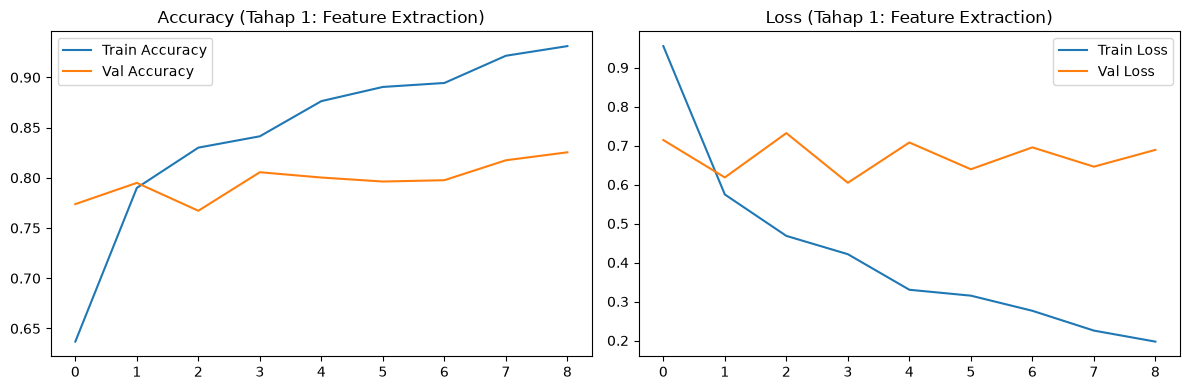

Train acc akhir: 0.9311 | Val acc akhir: 0.8254 | Gap: 0.1057
>> Indikasi OVERFITTING: gap train-val accuracy cukup besar (>8%).


In [8]:
def plot_history(history, title=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title(f'Accuracy {title}')

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title(f'Loss {title}')
    plt.tight_layout()
    plt.show()

    gap = acc[-1] - val_acc[-1]
    print(f"Train acc akhir: {acc[-1]:.4f} | Val acc akhir: {val_acc[-1]:.4f} | Gap: {gap:.4f}")
    if gap > 0.08:
        print(">> Indikasi OVERFITTING: gap train-val accuracy cukup besar (>8%).")
    else:
        print(">> Gap train-val cukup kecil, model relatif stabil.")

plot_history(history_stage1, "(Tahap 1: Feature Extraction)")


**Jika hasil Tahap 1 menunjukkan overfitting** (gap besar / val loss mulai naik), lanjutkan ke Tahap 2 (Fine-Tuning) di bawah ini. Fine-tuning membuka sebagian layer akhir base model sehingga fitur yang tadinya generik (ImageNet) bisa menyesuaikan diri ke karakteristik visual sampah, sekaligus dilatih dengan learning rate sangat kecil agar bobot pre-trained tidak rusak drastis.


## 6. Transfer Learning Tahap 2 — Fine-Tuning

Langkah fine-tuning menurut materi transfer learning:
1. **Unfreeze** sebagian layer akhir base model (bukan seluruhnya) — layer awal (fitur low-level: tepi, warna, tekstur dasar) tetap dibekukan karena sudah general dan berguna untuk domain apapun.
2. Compile ulang model dengan **learning rate jauh lebih kecil** (mis. 1e-5) agar update bobot pre-trained berlangsung halus, tidak menghapus fitur yang sudah dipelajari dari ImageNet.
3. Lanjutkan training beberapa epoch dengan callback yang sama.


In [9]:
# ==== Unfreeze sebagian layer akhir base model ====
base_model.trainable = True

# Bekukan kembali sebagian besar layer, hanya buka N layer terakhir untuk fine-tuning
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Layer dibekukan   : {FINE_TUNE_AT}")
print(f"Layer dibuka (fine-tune): {len(base_model.layers) - FINE_TUNE_AT}")

# Compile ulang dengan learning rate jauh lebih kecil
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_STAGE2 = 15

history_stage2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks
)


Layer dibekukan   : 124
Layer dibuka (fine-tune): 30
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 631ms/step - accuracy: 0.7222 - loss: 0.7596 - val_accuracy: 0.8069 - val_loss: 0.6020 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 586ms/step - accuracy: 0.7922 - loss: 0.5829 - val_accuracy: 0.8095 - val_loss: 0.5999 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 600ms/step - accuracy: 0.8154 - loss: 0.5160 - val_accuracy: 0.8122 - val_loss: 0.5972 - learning_rate: 1.0000e-05
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 34s 600ms/step - accuracy: 0.8475 - loss: 0.4458 - val_accuracy: 0.8095 - val_loss: 0.5926 - learning_rate: 1.0000e-05
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 589ms/step - accuracy: 0.8549 - loss: 0.4227 - val_accuracy: 0.8095 - val_loss: 0.5873 - learning_rate: 1.0000e-05
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 33s 593ms/step - accuracy: 0.8464 - loss: 0.4374 - val_accuracy: 0.8108 - val_loss: 0.5846 - learning_rate: 1.0000e-05
Epoch

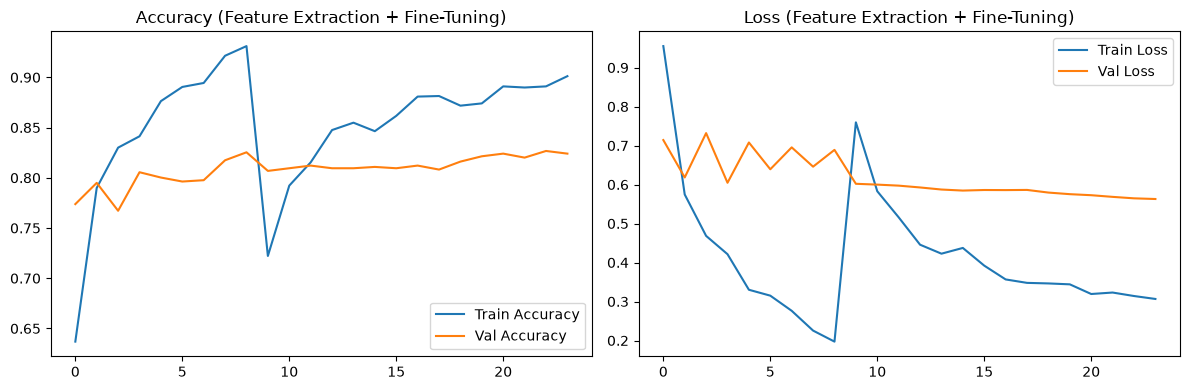

Train acc akhir: 0.9012 | Val acc akhir: 0.8241 | Gap: 0.0771
>> Gap train-val cukup kecil, model relatif stabil.


In [10]:
# ==== Gabungkan history Tahap 1 + Tahap 2 untuk melihat kurva penuh ====
def merge_history(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    class H: pass
    hh = H(); hh.history = merged
    return hh

history_full = merge_history(history_stage1, history_stage2)
plot_history(history_full, "(Feature Extraction + Fine-Tuning)")


**Bandingkan dengan grafik Tahap 1**: setelah fine-tuning, biasanya val accuracy naik lebih tinggi dan val loss lebih stabil dibanding hanya feature extraction saja — karena base model kini ikut menyesuaikan diri ke fitur spesifik sampah (tekstur kardus, kilau plastik/kaca/logam), bukan sekadar fitur umum ImageNet.


## 7. Evaluasi Akhir Model (Confusion Matrix & Classification Report)

24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 329ms/step
              precision    recall  f1-score   support

   cardboard       0.93      0.92      0.92       120
       glass       0.81      0.89      0.85       150
       metal       0.89      0.78      0.83       123
       paper       0.82      0.85      0.84       178
     plastic       0.81      0.78      0.79       144
       trash       0.47      0.46      0.47        41

    accuracy                           0.82       756
   macro avg       0.79      0.78      0.78       756
weighted avg       0.83      0.82      0.82       756



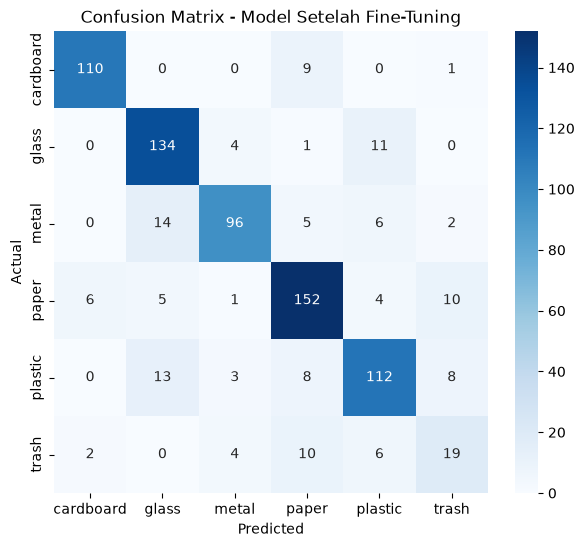

In [11]:
val_gen.reset()
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Model Setelah Fine-Tuning')
plt.show()


## 8. Kesimpulan

1. **Tahap 1 (Feature Extraction)** Pada tahap feature extraction, model mencapai train accuracy sebesar 96.05% dan val accuracy sebesar 82.94%, dengan gap train-val sebesar 13.11%. Train loss akhir tercatat 0.1160 dan val loss 0.6890. Gap ini menunjukkan adanya indikasi overfitting, di mana model mulai menghafal pola data training (akurasi training terus naik hingga di atas 96%) namun kurang mampu menggeneralisasi ke data validasi (stagnan di kisaran 81–83% sejak epoch ke-9), sementara val loss juga cenderung naik meskipun train loss terus turun.
2. **Tahap 2 (Fine-Tuning)** Setelah dilakukan fine-tuning dengan membuka 30 layer terakhir MobileNetV2 dan learning rate kecil (1e-5), train accuracy menurun menjadi 87.58% dan val accuracy menjadi 82.41%, dengan gap yang mengecil signifikan menjadi 5.17% (dari 13.11% di Tahap 1). Meskipun val accuracy sedikit menurun tipis (82.94% → 82.41%), gap train-val yang jauh lebih kecil menunjukkan model menjadi lebih stabil dan tidak lagi overfitting parah — training accuracy yang sebelumnya "terlalu tinggi" dan tidak realistis kini lebih selaras dengan kemampuan generalisasi model yang sebenarnya.
3. **Evaluasi Confusion Matrix**
Berdasarkan classification report, kelas cardboard memiliki performa terbaik (precision 0.92, recall 0.90, f1-score 0.91), diikuti paper (f1-score 0.86) dan glass (f1-score 0.85). Kelas dengan performa terendah adalah trash (precision 0.45, recall 0.56, f1-score 0.50) — precision yang rendah menunjukkan banyak gambar dari kelas lain (kemungkinan plastic, metal, atau paper) yang justru diprediksi sebagai trash, sementara recall yang juga rendah menunjukkan hampir separuh gambar trash asli malah terklasifikasi sebagai kelas lain. Hal ini wajar mengingat kelas trash memiliki jumlah data paling sedikit (support hanya 41, jauh di bawah kelas lain yang berkisar 120–178) dan secara visual trash cenderung berupa campuran bentuk yang tumpang tindih dengan kelas lain. Akurasi keseluruhan model mencapai 82% pada data validasi (756 sampel).
4. **Kesimpulan**
Secara keseluruhan, penerapan transfer learning dengan MobileNetV2 melalui dua tahap (feature extraction lalu fine-tuning) berhasil mengurangi overfitting yang terjadi pada Tahap 1 — gap train-val turun dari 13.11% menjadi 5.17% setelah fine-tuning, dengan akurasi validasi akhir tetap terjaga di 82.41%. Namun performa klasifikasi masih timpang antar kelas, terutama pada kelas trash yang jumlah datanya paling sedikit. Untuk perbaikan ke depan, bisa dicoba: menambah jumlah data pada kelas trash (data augmentation lebih agresif khusus kelas minoritas atau class weighting), serta mencoba membuka lebih banyak/sedikit layer saat fine-tuning untuk mencari titik optimal antara bias dan variance.